# Imports

In [1]:
from pathlib import Path
import re
import warnings

import esm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import ndcg_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

/Users/kevinbauer/anaconda3/envs/esm2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths

In [ ]:
# Paths
DATA_DIR = Path("../../data")
EXPERIMENTAL_DIR = DATA_DIR / "experimental_datasets"
DLG4_DIR = DATA_DIR / "test_data"
TOURNAMENT_DIR = DATA_DIR / "tournament"
PETASE_DIR = DATA_DIR / "PETase_zero_shot"
OUTPUT_DIR = Path("esm2_zero_shot_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "esm2_t33_650M_UR50D"

# Switch: "single" reproduces the current single-mutant setup.
#         "multi" allows variants with multiple substitutions, e.g. A123V:G145D.
MUTATION_MODE = "multi"  # choose: "single" or "multi"

if MUTATION_MODE not in {"single", "multi"}:
    raise ValueError("MUTATION_MODE must be either 'single' or 'multi'.")
OUTPUT_SUFFIX = "" if MUTATION_MODE == "single" else "_multi"
SCORE_COL = "ESM2"

# Single mutation pattern, e.g. A123V
MUTATION_RE = re.compile(r"^([A-Z])(\d+)([A-Z])$")

# Allowed separators for multi-mutants, e.g. A123V:G145D, A123V;G145D, A123V,G145D
MULTI_MUTATION_SPLIT_RE = re.compile(r"[:;,/\s]+")

# Reference WT sequences used for variant numbering in the benchmark datasets.
# Important: for UBE4B, GRB2 and PTEN, the variant positions refer to these canonical WT sequences,
# not necessarily to the per-row sequence column.
UBE4B_LONG_SEQ = "MEELSADEIRRRRLARLAGGQTSQPTTPLTSPQRENPPGPPIAASAPGPSQSLGLNVHNMTPATSPIGAAGVAHRSQSSEGVSSLSSSPSNSLETQSQSLSRSQSMDIDGVSCEKSMSQVDVDSGIENMEVDENDRREKRSLSDKEPSSGPEVSEEQALQLVCKIFRVSWKDRDRDVIFLSSLSAQFKQNPKEVFSDFKDLIGQILMEVLMMSTQTRDENPFASLTATSQPIATAARSPDRNLMLNTGSSSGTSPMFCNMGSFSTSSLSSLGASGGASNWDSYSDHFTIETCKETDMLNYLIECFDRVGIEEKKAPKMCSQPAVSQLLSNIRSQCISHTALVLQGSLTQPRSLQQPSFLVPYMLCRNLPYGFIQELVRTTHQDEEVFKQIFIPILQGLALAAKECSLESDYFKYPLMALGELCETKFGKTHPMCNLVASLPLWLPKSLSPGSGRELQRLSYLGAFFSFSVFAEDDAKVVEKYFSGPAITLENTRVVSQSLQHYLELGRQELFKILHSILLNGETREAALSYMAALVNANMKKAQMQADDRLVSTDGFMLNLLWVLQQLSTKIKLETVDPTYIFHPRCRITLPNDETRINATMEDVNERLTELYGDQPPFSEPKFPTECFFLTLHAHHLSILPSCRRYIRRLRAIRELNRTVEDLKNNESQWKDSPLATRHREMLKRCKTQLKKLVRCKACADAGLLDESFLRRCLNFYGLLIQLMLRILDPAYPDVTLPLNSEVPKVFAALPEFYVEDVAEFLFFIVQYSPQVLYEPCTQDIVMFLVVMLCNQNYIRNPYLVAKLVEVMFMTNPSVQPRTQKFFEMIENHPLSTKLLVPSLMKFYTDVEHTGATSEFYDKFTIRYHISTIFKSLWQNIAHHGTFMEEFNSGKQFVRYINMLINDTTFLLDESLESLKRIHEVQEEMKNKEQWDQLPRDQQQARQSQLAQDERVSRSYLALATETVDMFHLLTKQVQKPFLRPELGPRLAAMLNFNLQQLCGPKCRDLKVENPEKYGFEPKKLLDQLTDIYLQLDCARFAKAIADDQRSYSKELFEEVISKMRKAGIKSTIAIEKFKLLAEKVEEIVAKNARAEIDYSDAPDEFRDPLMDTLMTDPVRLPSGTVMDRSIILRHLLNSPTDPFNRQMLTESMLEPVPELKEQIQAWMREKQSSDH"

GRB2_LONG_SEQ = "MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFNSLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVNRNV"

PTEN_LONG_SEQ = "MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVYRNNIDDVVRFLDSKHKNHYKIYNLCAERHYDTAKFNCRVAQYPFEDHNPPQLELIKPFCEDLDQWLSEDDNHVAAIHCKAGKGRTGVMICAYLLHRGKFLKAQEALDFYGEVRTRDKKGVTIPSQRRYVYYYSYLLKNHLDYRPVALLFHKMMFETIPMFSGGTCNPQFVVCQLKVKIYSSNSGPTRREDKFMYFEFPQPLPVCGDIKVEFFHKQNKMLKKDKMFHFWVNTFFIPGPEETSEKVENGSLCDQEIDSICSIERADNDKEYLVLTLTKNDLDKANKDKANRYFSPNFKVKLYFTKTVEEPSNPEASSSTSVTPDVSDNEPDHYRYSDTTDSDPENEPFDEDQHTQITKV"

DATASET_CONFIG = {
    "UBE4B": {
        "path": EXPERIMENTAL_DIR / "ube4b_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": UBE4B_LONG_SEQ,
    },
    "GRB2": {
        "path": EXPERIMENTAL_DIR / "grb2_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": GRB2_LONG_SEQ,
    },
    "PTEN_activity": {
        "path": EXPERIMENTAL_DIR / "pten-activity_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": PTEN_LONG_SEQ,
    },
    "PTEN_abundance": {
        "path": EXPERIMENTAL_DIR / "pten-abundance_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": PTEN_LONG_SEQ,
    },
    "Alpha-Amylase": {
        "path": TOURNAMENT_DIR / "Alpha-Amylase with WT(in silico_ Zero Shot).csv",
        "sep": "\t",
        "variant_col": "mutant",
        "sequence_col": "mutated_sequence",
        "target_cols": ["expression", "thermostability", "specific activity"],
        "position_base": 1,
        "reconstruct_wt": True,
    },
    "PETase": {
        "path": PETASE_DIR / "petase_zero_shot_full_dataset.csv",
        "sep": ",",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": [],
        "position_base": 1,
    },
    "DLG4_abundance": {
        "path": DLG4_DIR / "dlg4-2022-abundance.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
    },
    "DLG4_binding": {
        "path": DLG4_DIR / "dlg4-2022-binding.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
    }
}

# ESM-2 Modell

In [37]:
def load_esm2_model(model_name: str = MODEL_NAME, device: str | None = None):
    """Load ESM-2 model, alphabet and batch converter."""
    model, alphabet = getattr(esm.pretrained, model_name)()
    model.eval()

    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model = model.to(device)
    batch_converter = alphabet.get_batch_converter()
    print(f"Loaded {model_name} on {device}")
    return model, alphabet, batch_converter, device


def parse_single_mutation(mutation: str):
    """Parse a single mutation such as A123V."""
    match = MUTATION_RE.match(str(mutation).strip().upper())
    if match is None:
        return None

    wt_aa, pos, mut_aa = match.groups()
    return wt_aa, int(pos), mut_aa


def parse_variant(variant: str, mutation_mode: str = MUTATION_MODE):
    """Parse either a single mutant or a multi-mutant.

    Returns a list of tuples:
        [(wt_aa, position, mut_aa), ...]

    Examples:
        A123V -> [("A", 123, "V")]
        A123V:G145D -> [("A", 123, "V"), ("G", 145, "D")]
    """
    variant = str(variant).strip().upper()

    if variant in {"", "WT", "WILDTYPE", "NAN"}:
        return None

    parts = [p for p in MULTI_MUTATION_SPLIT_RE.split(variant) if p]

    parsed_mutations = []
    for part in parts:
        parsed = parse_single_mutation(part)
        if parsed is None:
            return None
        parsed_mutations.append(parsed)

    if len(parsed_mutations) == 0:
        return None

    if mutation_mode == "single" and len(parsed_mutations) != 1:
        return None

    return parsed_mutations


def to_sequence_position_1based(variant_position: int, position_base: int) -> int:
    """Convert variant numbering to 1-based sequence numbering."""
    if position_base == 0:
        return variant_position + 1
    if position_base == 1:
        return variant_position
    raise ValueError("position_base must be either 0 or 1")


def reconstruct_wild_type_sequence(
    mutated_sequence: str,
    mutations: list[tuple[str, int, str]],
    position_base: int,
) -> str:
    """Reconstruct WT sequence if only the mutated sequence is available.

    For multi-mutants, all mutated positions are reset to their WT amino acid.
    """
    seq = list(str(mutated_sequence))

    for wt_aa, variant_pos, mut_aa in mutations:
        position_1based = to_sequence_position_1based(variant_pos, position_base)

        if position_1based < 1 or position_1based > len(seq):
            continue

        seq[position_1based - 1] = wt_aa

    return "".join(seq)

In [38]:
def esm2_log_odds(
    sequence: str,
    position_1based: int,
    wt_aa: str,
    mut_aa: str,
    model,
    alphabet,
    batch_converter,
    device: str,
) -> float:
    """Compute log P(mutant residue) - log P(wild-type residue) at one masked position."""
    _, _, tokens = batch_converter([("seq", sequence)])
    tokens = tokens.to(device)

    masked_tokens = tokens.clone()
    masked_tokens[0, position_1based] = alphabet.mask_idx

    with torch.no_grad():
        logits = model(masked_tokens, repr_layers=[], return_contacts=False)["logits"][0, position_1based]

    log_probs = torch.log_softmax(logits, dim=-1)
    wt_log_prob = log_probs[alphabet.tok_to_idx[wt_aa]].item()
    mut_log_prob = log_probs[alphabet.tok_to_idx[mut_aa]].item()

    return float(mut_log_prob - wt_log_prob)

def esm2_variant_score(
    sequence: str,
    mutations: list[tuple[str, int, str]],
    *,
    position_base: int,
    model,
    alphabet,
    batch_converter,
    device: str,
) -> float:
    """Compute an additive ESM-2 score for single- or multi-mutants.

    For multi-mutants, the score is the sum of individual masked-marginal log-odds:
        sum_i [log P(mut_i) - log P(wt_i)]
    """
    total_score = 0.0

    for wt_aa, variant_pos, mut_aa in mutations:
        position_1based = to_sequence_position_1based(variant_pos, position_base)

        single_score = esm2_log_odds(
            sequence=sequence,
            position_1based=position_1based,
            wt_aa=wt_aa,
            mut_aa=mut_aa,
            model=model,
            alphabet=alphabet,
            batch_converter=batch_converter,
            device=device,
        )

        total_score += single_score

    return float(total_score)


def add_esm2_scores(
    df: pd.DataFrame,
    *,
    variant_col: str = "variant",
    sequence_col: str = "sequence",
    position_base: int = 1,
    wt_sequence: str | None = None,
    reconstruct_wt: bool = False,
    model=None,
    alphabet=None,
    batch_converter=None,
    device: str | None = None,
    score_col: str = SCORE_COL,
    mutation_mode: str = MUTATION_MODE,
) -> pd.DataFrame:
    """Add ESM-2 zero-shot log-odds scores to a dataframe.

    In single mode, only variants with exactly one substitution are scored.
    In multi mode, variants with one or more substitutions are scored additively.
    """
    df = df.copy()
    df[score_col] = np.nan

    skipped = {
        "invalid_variant": 0,
        "position_out_of_range": 0,
        "wt_mismatch": 0,
        "unknown_aa": 0,
    }

    for idx in tqdm(df.index, total=len(df)):
        mutations = parse_variant(df.at[idx, variant_col], mutation_mode=mutation_mode)

        if mutations is None:
            skipped["invalid_variant"] += 1
            continue

        if wt_sequence is not None:
            sequence = wt_sequence
        else:
            sequence = str(df.at[idx, sequence_col])

        if reconstruct_wt:
            sequence = reconstruct_wild_type_sequence(
                mutated_sequence=sequence,
                mutations=mutations,
                position_base=position_base,
            )

        valid = True

        for wt_aa, variant_pos, mut_aa in mutations:
            position_1based = to_sequence_position_1based(variant_pos, position_base)

            if position_1based < 1 or position_1based > len(sequence):
                skipped["position_out_of_range"] += 1
                valid = False
                break

            if sequence[position_1based - 1] != wt_aa:
                skipped["wt_mismatch"] += 1
                valid = False
                break

            if wt_aa not in alphabet.tok_to_idx or mut_aa not in alphabet.tok_to_idx:
                skipped["unknown_aa"] += 1
                valid = False
                break

        if not valid:
            continue

        df.at[idx, score_col] = esm2_variant_score(
            sequence=sequence,
            mutations=mutations,
            position_base=position_base,
            model=model,
            alphabet=alphabet,
            batch_converter=batch_converter,
            device=device,
        )

    skipped = {k: v for k, v in skipped.items() if v > 0}
    if skipped:
        print("Skipped rows:", skipped)

    return df

# Correlation Metrics

In [39]:
def ndcg_at_fraction(pred, true, frac: float = 0.10) -> float:
    """NDCG at top fraction. Experimental values are shifted to be non-negative."""
    pred = pd.to_numeric(pd.Series(pred), errors="coerce").to_numpy(dtype=float)
    true = pd.to_numeric(pd.Series(true), errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(pred) & np.isfinite(true)
    pred, true = pred[mask], true[mask]

    if len(true) < 3:
        return np.nan

    k = max(1, min(int(np.ceil(frac * len(true))), len(true)))
    true_shifted = true - np.min(true)

    if np.max(true_shifted) == 0:
        return np.nan

    return float(ndcg_score(true_shifted.reshape(1, -1), pred.reshape(1, -1), k=k))


def evaluate_scores(df: pd.DataFrame, target_col: str, score_col: str = SCORE_COL) -> dict:
    x = pd.to_numeric(df[target_col], errors="coerce")
    y = pd.to_numeric(df[score_col], errors="coerce")
    mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return {"n": int(mask.sum()), "pearson": np.nan, "spearman": np.nan, "ndcg@10%": np.nan}

    x_values = x[mask].to_numpy(float)
    y_values = y[mask].to_numpy(float)

    return {
        "n": int(mask.sum()),
        "pearson": pearsonr(x_values, y_values).statistic,
        "spearman": spearmanr(x_values, y_values).correlation,
        "ndcg@10%": ndcg_at_fraction(y_values, x_values, frac=0.10),
    }


def plot_scores(df: pd.DataFrame, dataset_name: str, target_col: str, score_col: str = SCORE_COL):
    x = pd.to_numeric(df[target_col], errors="coerce")
    y = pd.to_numeric(df[score_col], errors="coerce")
    mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        print(f"Not enough data points for {dataset_name} / {target_col}")
        return

    metrics = evaluate_scores(df, target_col=target_col, score_col=score_col)

    plt.figure(figsize=(7, 5))
    plt.scatter(x[mask], y[mask], alpha=0.5)
    plt.xlabel(target_col)
    plt.ylabel(score_col)
    plt.title(f"{dataset_name}: {score_col} vs. {target_col}")
    plt.text(
        0.05,
        0.90,
        f"Spearman = {metrics['spearman']:.3f}\nNDCG@10% = {metrics['ndcg@10%']:.3f}",
        transform=plt.gca().transAxes,
    )
    plt.tight_layout()
    plt.show()

# Load all datasets and model

In [ ]:
def load_dataset(dataset_name: str, mutation_mode: str = MUTATION_MODE) -> tuple[pd.DataFrame, dict]:
    config = DATASET_CONFIG[dataset_name]
    df = pd.read_csv(config["path"], sep=config["sep"])

    if config["variant_col"] != "variant" and config["variant_col"] in df.columns:
        df = df.rename(columns={config["variant_col"]: "variant"})
        config = {**config, "variant_col": "variant"}

    if "num_mutations" in df.columns:
        if mutation_mode == "single":
            df = df.loc[df["num_mutations"] == 1].copy()
        elif mutation_mode == "multi":
            df = df.loc[df["num_mutations"] > 1].copy()

    return df, config


model, alphabet, batch_converter, device = load_esm2_model(MODEL_NAME)

Loaded esm2_t33_650M_UR50D on mps



===== GRB2 =====


100%|██████████| 63366/63366 [3:07:55<00:00,  5.62it/s]  


Saved: esm2_zero_shot_outputs/GRB2_with_esm2_multi.csv
score: {'n': 63366, 'pearson': np.float64(0.6395490638509447), 'spearman': np.float64(0.6474108305194294), 'ndcg@10%': 0.8673119360918341}


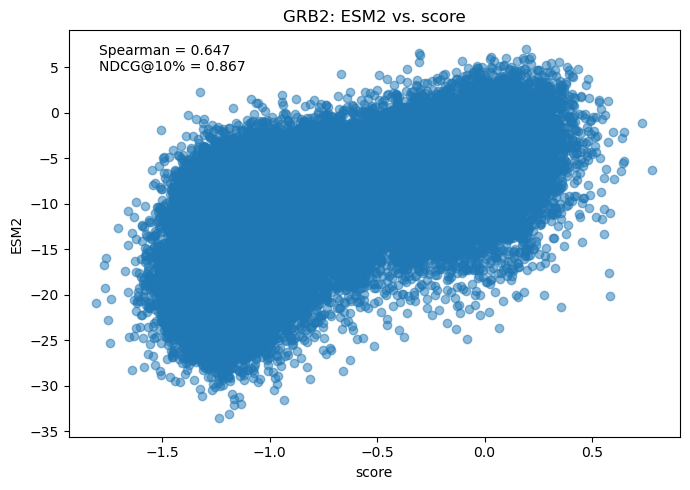


===== PTEN_activity =====


100%|██████████| 6564/6564 [17:15<00:00,  6.34it/s]


Saved: esm2_zero_shot_outputs/PTEN_activity_with_esm2_multi.csv
score: {'n': 6564, 'pearson': np.float64(0.584818673548912), 'spearman': np.float64(0.5632520468712758), 'ndcg@10%': 0.8770542864641323}


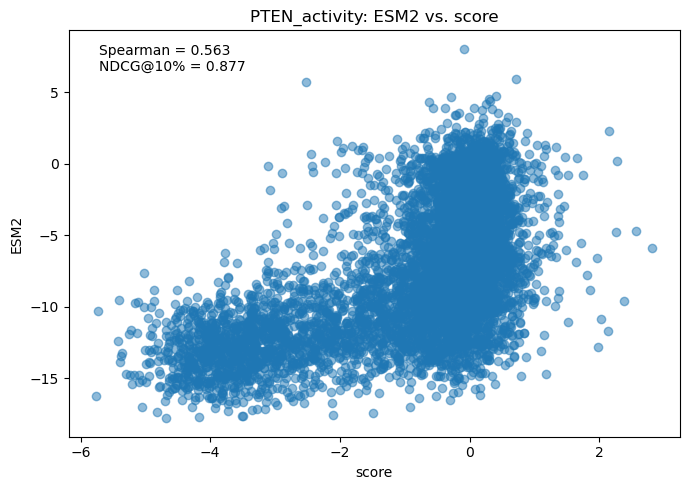


===== PTEN_abundance =====


100%|██████████| 4387/4387 [11:31<00:00,  6.34it/s]


Saved: esm2_zero_shot_outputs/PTEN_abundance_with_esm2_multi.csv
score: {'n': 4387, 'pearson': np.float64(0.49654667345093867), 'spearman': np.float64(0.48509329585168254), 'ndcg@10%': 0.8175542094195051}


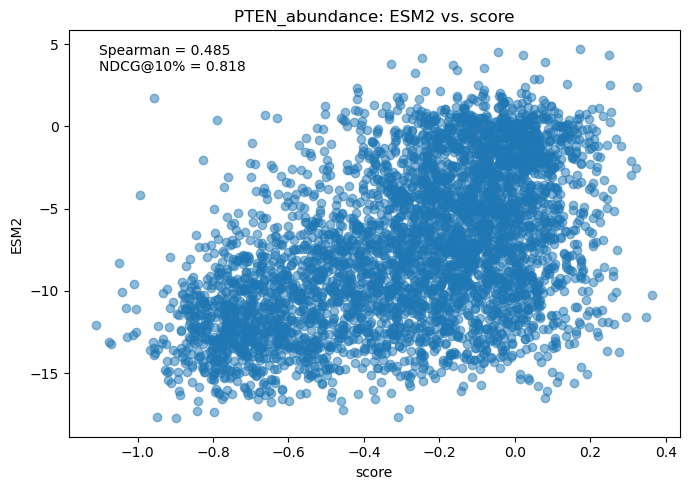


===== DLG4_abundance =====


100%|██████████| 6976/6976 [09:20<00:00, 12.44it/s]


Saved: esm2_zero_shot_outputs/DLG4_abundance_with_esm2_multi.csv
score: {'n': 6976, 'pearson': np.float64(0.6342426432529256), 'spearman': np.float64(0.6378907520559122), 'ndcg@10%': 0.8655177784528991}


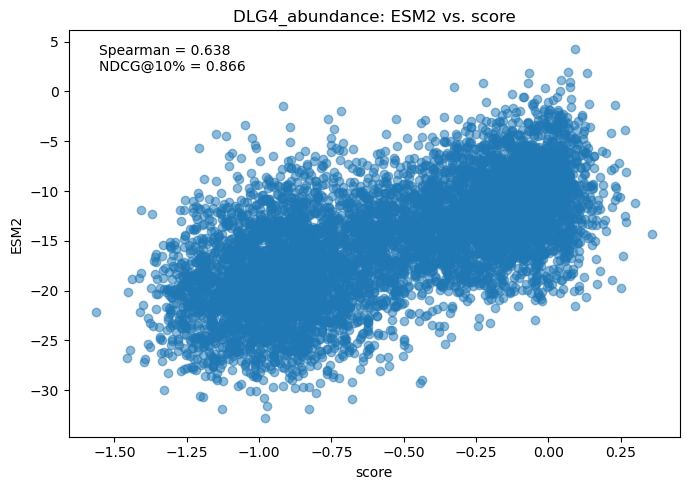


===== DLG4_binding =====


100%|██████████| 8251/8251 [11:02<00:00, 12.46it/s]

Saved: esm2_zero_shot_outputs/DLG4_binding_with_esm2_multi.csv
score: {'n': 8251, 'pearson': np.float64(0.6638397023295067), 'spearman': np.float64(0.6645697612519124), 'ndcg@10%': 0.8874779113350516}


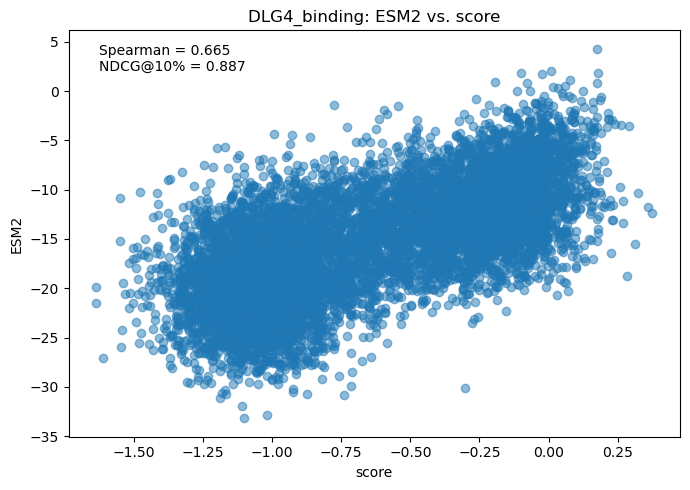

,dataset,target,n,pearson,spearman,ndcg@10%
0,GRB2,score,63366,0.640,0.647,0.867
1,PTEN_activity,score,6564,0.585,0.563,0.877
2,PTEN_abundance,score,4387,0.497,0.485,0.818
3,DLG4_abundance,score,6976,0.634,0.638,0.866
4,DLG4_binding,score,8251,0.664,0.665,0.887


In [ ]:
# Run ESM-2 zero-shot scoring for the benchmark datasets
benchmark_names = ["UBE4B", "GRB2", "PTEN_activity", "PTEN_abundance", "DLG4_abundance", "DLG4_binding"]

scored_datasets = {}
benchmark_metrics = []

for dataset_name in benchmark_names:
    print(f"\n===== {dataset_name} =====")
    df, config = load_dataset(dataset_name, mutation_mode=MUTATION_MODE)
    # TEST_RUN = False
    # N_TEST = 20

    # if TEST_RUN and "num_mutations" in df.columns:
    #     df_test_single = df.loc[df["num_mutations"] == 1].head(5)
    #     df_test_multi = df.loc[df["num_mutations"] > 1].head(N_TEST - 5)
    #     df = pd.concat([df_test_single, df_test_multi], axis=0).copy()

    #     print("TEST_RUN active")
    #     print(df["num_mutations"].value_counts().sort_index())

    df_scored = add_esm2_scores(
        df,
        variant_col=config["variant_col"],
        sequence_col=config["sequence_col"],
        position_base=config["position_base"],
        wt_sequence=config.get("wt_sequence"),
        reconstruct_wt=config.get("reconstruct_wt", False),
        model=model,
        alphabet=alphabet,
        batch_converter=batch_converter,
        device=device,
        mutation_mode=MUTATION_MODE,
    )

    out_path = OUTPUT_DIR / f"{dataset_name}_with_esm2{OUTPUT_SUFFIX}.csv"
    df_scored.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    for target_col in config["target_cols"]:
        metrics = evaluate_scores(df_scored, target_col=target_col)
        benchmark_metrics.append({"dataset": dataset_name, "target": target_col, **metrics})
        print(f"{target_col}: {metrics}")
        plot_scores(df_scored, dataset_name, target_col)

    scored_datasets[dataset_name] = df_scored

benchmark_metrics_df = pd.DataFrame(benchmark_metrics)
display(benchmark_metrics_df.round(3))